## Sprint 6 - Proyecto

### Proyecto Integrado - Jorge Alejandro Cely Naranjo

#### Objetivo del Proyecto

El objetivo del proyecto es identificar patrones que determinen si un juego tiene éxito o no para detercar proyectos prometedores y planificar campañas publicitarias.

#### Importar Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from pathlib import Path

#### Paso 1. Abre el archivo de datos y estudia la información general 

#### Cargar Datos

In [2]:
# Ruta relativa desde la carpeta del notebook (desarrollo/) al CSV en data/
csv_path = Path.cwd().parent / 'data' / 'games.csv'

df = pd.read_csv(csv_path)

In [3]:
# Información general inicial
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Información general inicial
print('\nVista previa:')
display(df.head())


Vista previa:


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
df.sample(n=5)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16704,Plushees,DS,2008.0,Simulation,0.01,0.00,0.00,0.00,NaN,tbd,E
14225,Battle Engine Aquila,PS2,2003.0,Shooter,0.02,0.01,0.00,0.00,73.0,9,T
5637,Tetris 2 + Bombliss,NES,1991.0,Puzzle,0.00,0.00,0.32,0.00,NaN,NaN,NaN
11876,Prey the Stars,DS,2008.0,Action,0.07,0.00,0.00,0.01,66.0,tbd,E
11110,Karaoke Revolution Presents American Idol Enco...,X360,2008.0,Misc,0.08,0.00,0.00,0.01,NaN,tbd,E10+


In [6]:
print('\nShape:', df.shape)


Shape: (16715, 11)


In [7]:
print('\nTipos originales:')
display(df.dtypes)


Tipos originales:


Name                object
Platform            object
Year_of_Release    float64
Genre               object
NA_sales           float64
EU_sales           float64
JP_sales           float64
Other_sales        float64
Critic_Score       float64
User_Score          object
Rating              object
dtype: object

#### Paso 2. Prepara los datos

In [8]:
# Normalizar nombres de columnas
old_columns = df.columns.tolist()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('\nColumnas renombradas a minúsculas y guiones bajos:')
print('Antes -> Después')
for o, n in zip(old_columns, df.columns.tolist()):
    print(f"{o} -> {n}")


Columnas renombradas a minúsculas y guiones bajos:
Antes -> Después
Name -> name
Platform -> platform
Year_of_Release -> year_of_release
Genre -> genre
NA_sales -> na_sales
EU_sales -> eu_sales
JP_sales -> jp_sales
Other_sales -> other_sales
Critic_Score -> critic_score
User_Score -> user_score
Rating -> rating


In [9]:
# Reemplazar 'tbd' (cualquier combinación de mayúsc/minúsc y espacios) por NA
df.replace(to_replace=r'^\s*tbd\s*$', value=pd.NA, regex=True, inplace=True)

In [10]:
# Detectar columnas de ventas
sales_cols = [c for c in df.columns if c.endswith('_sales') and c != 'global_sales']
print('\nColumnas de ventas detectadas:', sales_cols)


Columnas de ventas detectadas: ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']


In [11]:
# Convertir ventas a numérico (float) y rellenar NaN con 0 (asumimos ventas no reportadas = 0)
df[sales_cols] = df[sales_cols].apply(pd.to_numeric, errors='coerce')
df[sales_cols] = df[sales_cols].fillna(0.0)

In [12]:
# Convertir year_of_release a entero nullable
if 'year_of_release' in df.columns:
    df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
    df['year_of_release'] = df['year_of_release'].astype('Int64')

In [13]:
# Convertir puntuaciones a numéricas (critic_score puede ser 0-100, user_score 0-10), dejar NaN donde falta
for col in ['critic_score', 'user_score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
# Convertir columnas categóricas a 'category'
for col in ['platform', 'genre', 'rating', 'publisher']:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [15]:
# Calcular ventas totales globales
if sales_cols:
    df['global_sales'] = df[sales_cols].sum(axis=1)
else:
    # si no hay columnas con sufijo _sales, intentar detectar columnas por nombres comunes
    possible = [c for c in df.columns if 'na' in c or 'eu' in c or 'jp' in c]
    df['global_sales'] = df[possible].sum(axis=1) if possible else 0

In [16]:
# Mostrar cambios de tipos
print('\nTipos después de la conversión:')
display(df.dtypes)


Tipos después de la conversión:


name                 object
platform           category
year_of_release       Int64
genre              category
na_sales            float64
eu_sales            float64
jp_sales            float64
other_sales         float64
critic_score        float64
user_score          float64
rating             category
global_sales        float64
dtype: object

In [17]:
# Resumen de valores ausentes
print('\nConteo de valores ausentes por columna:')
display(df.isna().sum())


Conteo de valores ausentes por columna:


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
global_sales          0
dtype: int64

Decisiones tomadas sobre valores ausentes:
- Se reemplazó 'TBD' por NA porque indica dato pendiente/indeterminado.
- Columnas de ventas: NaNs rellenadas con 0.0 (interpretación: sin ventas reportadas).
- `year_of_release`: convertida a entero nullable; si falta, se mantendrá NA para evitar suposiciones.
- `critic_score` y `user_score`: convertidas a numéricas y mantenidas NA cuando falten. No se imputaron.

Posibles razones de valores ausentes:
- Datos no reportados por la fuente (ventas cero o falta de registro).
- Títulos aún sin fecha de lanzamiento ('TBD').
- Errores o inconsistencias en la base de datos original.



In [18]:
# Mostrar primeras filas del DataFrame limpio
print('\nVista previa del DataFrame limpio:')
display(df.sample(n=5))


Vista previa del DataFrame limpio:


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
12528,Arkanoid DS,DS,2007,Puzzle,0.06,0.00,0.00,0.00,61.0,7.0,E,0.06
13961,Wicked Monster Blast!,Wii,2011,Shooter,0.03,0.00,0.00,0.00,NaN,NaN,NaN,0.03
7342,Puss in Boots,Wii,2011,Action,0.19,0.01,0.00,0.01,NaN,NaN,E10+,0.21
10490,Riviera: The Promised Land,GBA,2004,Role-Playing,0.07,0.03,0.00,0.00,76.0,9.2,T,0.10
10366,Naruto Shippuden 3D: The New Era,3DS,2011,Action,0.00,0.04,0.06,0.01,NaN,NaN,NaN,0.11


In [19]:
output_dir = Path.cwd().parent / 'outputs'
output_dir.mkdir(exist_ok=True)

# Asegurarnos de tener `df` en memoria (se creó en pasos anteriores)
print('Filas en df:', len(df))

Filas en df: 16715


#### 1) Juegos por año

In [20]:
# 1) Juegos por año
years = df['year_of_release'].dropna().astype(int)
games_per_year = years.value_counts().sort_index()
print('\nRango de años:', games_per_year.index.min(), '-', games_per_year.index.max())
print('\nJuegos por año (muestra):')
print(games_per_year.head(10))


Rango de años: 1980 - 2016

Juegos por año (muestra):
year_of_release
1980     9
1981    46
1982    36
1983    17
1984    14
1985    14
1986    21
1987    16
1988    15
1989    17
Name: count, dtype: int64


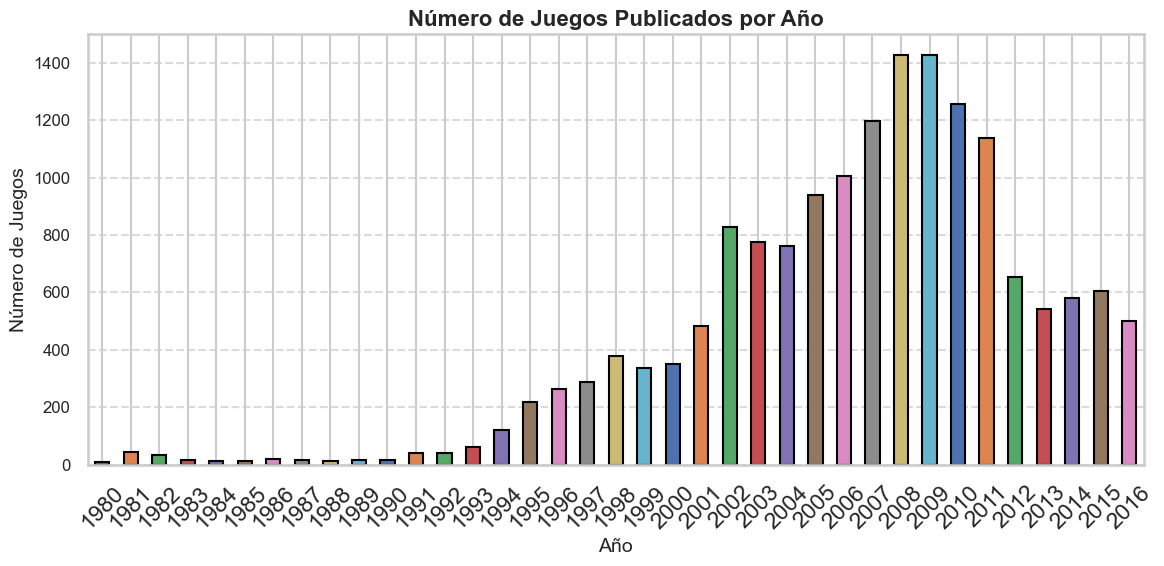

In [21]:
sns.set_style("whitegrid")
sns.set_context("talk")  # Ajusta tamaño de fuentes para presentaciones

plt.figure(figsize=(12, 6))
ax = games_per_year.plot(
    kind='bar',
    color=sns.color_palette("deep"),  # Paleta profesional
    edgecolor='black'
)

# Títulos y etiquetas con formato
ax.set_title('Número de Juegos Publicados por Año', fontsize=16, fontweight='bold')
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Número de Juegos', fontsize=14)

# Ajustes de ejes y ticks
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=12)

# Grid discreto solo en eje Y
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Layout y exportación
plt.tight_layout()
plt.savefig(output_dir / 'games_per_year.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [22]:
# Decadear y ver si hay suficientes datos por periodo
df['decade'] = (df['year_of_release'] // 10 * 10).astype('Int64')
decade_stats = df.groupby('decade').agg(games_count=('name','count'), sales_sum=('global_sales','sum')).sort_index()
print('\nEstadísticas por década:')
display(decade_stats)


Estadísticas por década:


,games_count,sales_sum
decade,,
1980,205,376.48
1990,1769,1281.16
2000,9193,4614.91
2010,5277,2544.24


¿Son significativos los datos de cada período?
- No todos los datos de cada periodo son significativos. Únicamente los datos de la década del 2000 y del 2010 son significativos.

#### 2) Variación de ventas por plataforma

In [23]:
# 2) Variación de ventas por plataforma
platform_sales = df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
print('\nPlataformas con mayores ventas totales (top 15):')
print(platform_sales.head(15))

top_platforms = platform_sales.head(10).index.tolist()


Plataformas con mayores ventas totales (top 15):
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
Name: global_sales, dtype: float64


C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\196178647.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_sales = df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)


#### Top 10 Plataformas por Ventas Totales

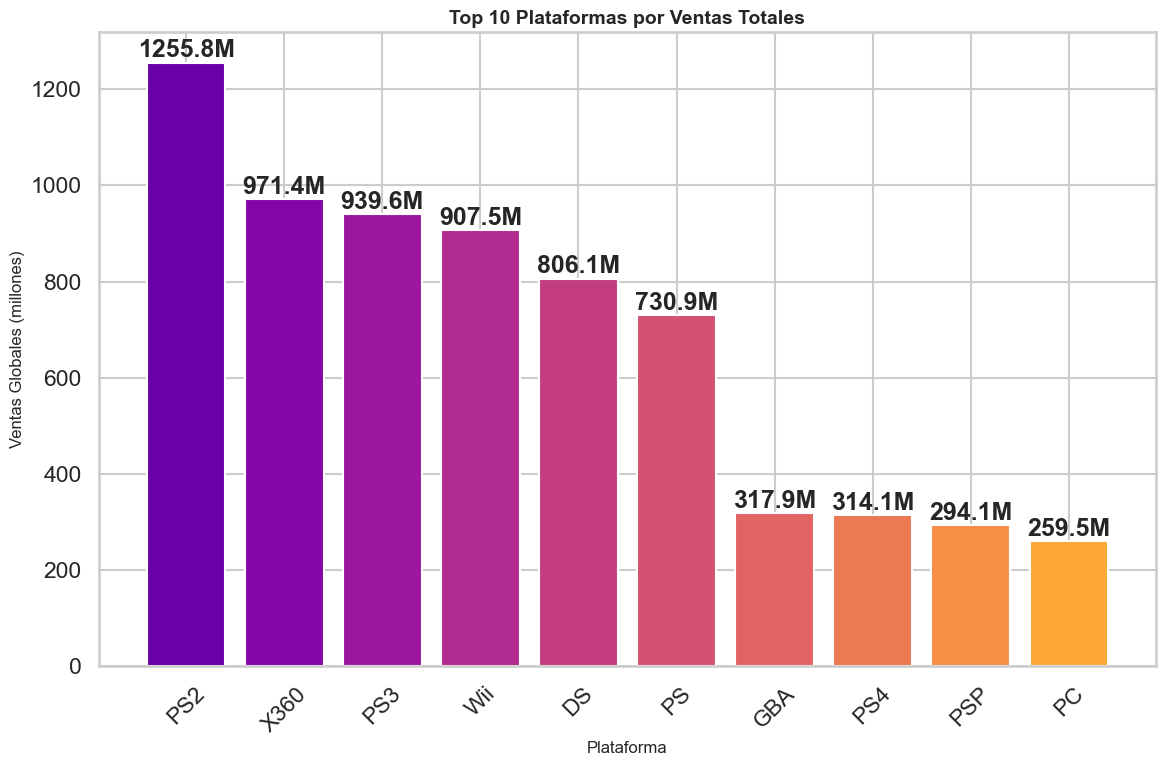

In [24]:
# Datos para las top 10 plataformas
top_platforms_data = platform_sales.head(10)

plt.figure(figsize=(12, 8))

# Crear gradiente de azul a morado
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_platforms_data)))

bars = plt.bar(top_platforms_data.index, top_platforms_data.values, color=colors)

# Agregar valores encima de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.title('Top 10 Plataformas por Ventas Totales', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Globales (millones)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Distribución de Ventas por Año - Top 10 Plataformas

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\3314144951.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_year_sales = top_data.groupby(['year_of_release','platform'])['global_sales'].sum().reset_index()


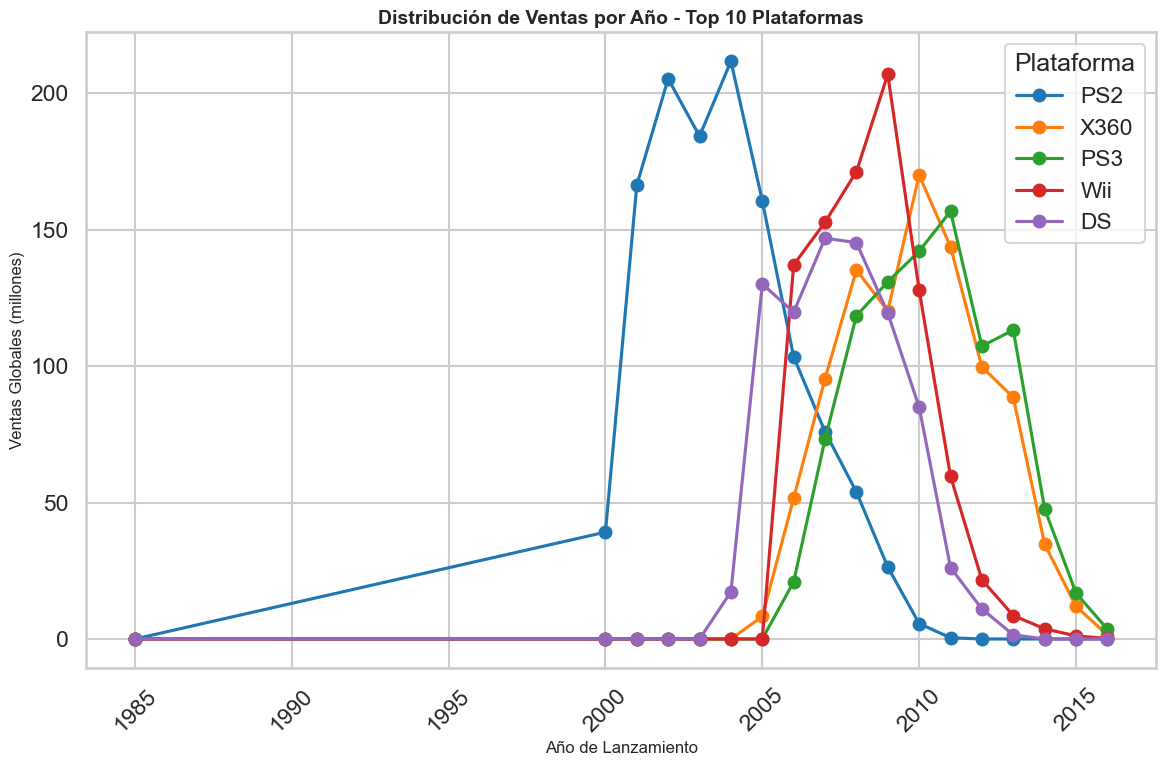

In [25]:
top_platforms = platform_sales.head(5).index

# 3. Filtrar el dataframe solo con esas plataformas
top_data = df[df['platform'].isin(top_platforms)]

# 4. Agrupar por año y plataforma
platform_year_sales = top_data.groupby(['year_of_release','platform'])['global_sales'].sum().reset_index()

# 5. Graficar cada plataforma como una línea
plt.figure(figsize=(12, 8))
for platform in top_platforms:
    data = platform_year_sales[platform_year_sales['platform'] == platform]
    plt.plot(data['year_of_release'], data['global_sales'], marker='o', label=platform)

plt.title('Distribución de Ventas por Año - Top 10 Plataformas', fontsize=14, fontweight='bold')
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Globales (millones)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

#### Plataformas que solían ser populares pero que ahora no tienen ventas

In [26]:
# 1. Período pasado (antes de 2012)
past_period = (2000, 2011)  # ajusta según tu dataset
past_df = df[(df['year_of_release'] >= past_period[0]) & (df['year_of_release'] <= past_period[1])]
past_platform_sales = past_df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
top_past_platforms = past_platform_sales.head(10).index

print("Top plataformas en 2000–2011:")
print(past_platform_sales.head(10))

# 2. Período reciente (2012–2016)
recent_period = (2012, 2016)
recent_df = df[(df['year_of_release'] >= recent_period[0]) & (df['year_of_release'] <= recent_period[1])]
recent_platform_sales = recent_df.groupby('platform')['global_sales'].sum()

# 3. Comparar: plataformas populares antes pero con ventas nulas en 2012–2016
inactive_platforms = [p for p in top_past_platforms if recent_platform_sales.get(p, 0) == 0]

print("\nPlataformas que solían ser populares pero ya no tienen ventas en 2012–2016:")
print(inactive_platforms)

Top plataformas en 2000–2011:
platform
PS2     1233.56
Wii      855.81
DS       790.21
X360     724.70
PS3      642.55
GBA      312.88
PSP      278.34
XB       251.57
GC       196.73
PC       143.07
Name: global_sales, dtype: float64

Plataformas que solían ser populares pero ya no tienen ventas en 2012–2016:
['PS2', 'GBA', 'XB', 'GC']


C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\1855136699.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  past_platform_sales = past_df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\1855136699.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recent_platform_sales = recent_df.groupby('platform')['global_sales'].sum()


Plataformas que solían ser populares pero que ahora no tienen ventas:
- PS2, GBA, SB, GC.

#### Tiempo que tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer

In [27]:
# 1. Primer año de ventas por plataforma
first_year = df.groupby('platform')['year_of_release'].min()

# 2. Último año de ventas por plataforma
last_year = df.groupby('platform')['year_of_release'].max()

# 3. Duración de vida útil (años activos)
lifespan = last_year - first_year

# 4. Construir tabla resumen
platform_lifecycle = pd.DataFrame({
    'Año aparición': first_year,
    'Año desaparición': last_year,
    'Duración (años)': lifespan
}).sort_values('Año aparición')

print("Tabla de ciclos de vida por plataforma:")
print(platform_lifecycle.sample(n=5))

# 5. Promedios generales
avg_lifespan = lifespan.mean()
sorted_first = first_year.sort_values()
avg_gap = sorted_first.diff().mean()

print("\nResumen ejecutivo:")
print(f"- En promedio, las plataformas duran {avg_lifespan:.1f} años antes de desaparecer.")
print(f"- En promedio, aparece una nueva plataforma cada {avg_gap:.1f} años.")

Tabla de ciclos de vida por plataforma:
          Año aparición  Año desaparición  Duración (años)
platform                                                  
PCFX               1996              1996                0
NG                 1993              1996                3
N64                1996              2002                6
3DO                1994              1995                1
NES                1983              1994               11

Resumen ejecutivo:
- En promedio, las plataformas duran 7.6 años antes de desaparecer.
- En promedio, aparece una nueva plataforma cada 1.1 años.


C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\184440012.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  first_year = df.groupby('platform')['year_of_release'].min()
C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\184440012.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_year = df.groupby('platform')['year_of_release'].max()


¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
- En promedio, las plataformas duran 7.6 años antes de desaparecer.
- En promedio, aparece una nueva plataforma cada 1.1 años.

#### Datos para Modelo 2017

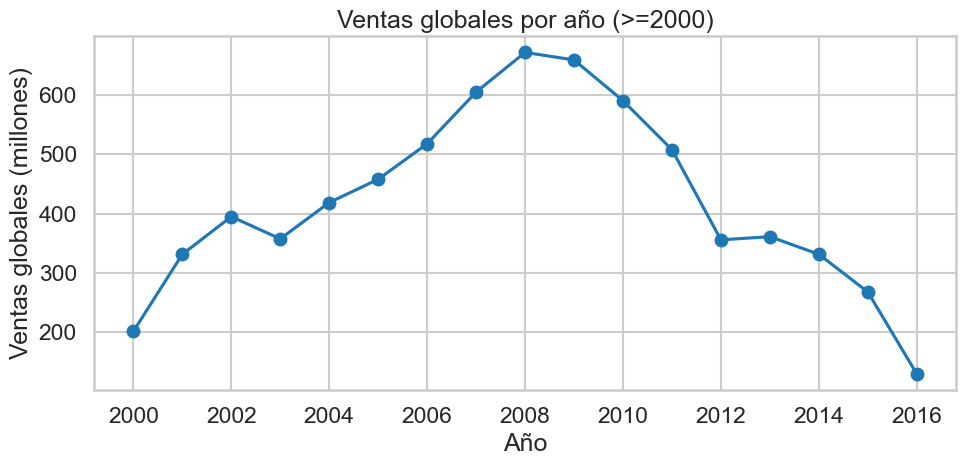


Ventas totales por año (2000 en adelante):
year_of_release
2007    604.75
2008    671.50
2009    658.82
2010    590.13
2011    507.58
2012    355.84
2013    361.24
2014    331.53
2015    267.98
2016    129.94
Name: global_sales, dtype: float64


In [28]:
# 5) Selección de periodo relevante para modelar 2017

# Mostrar ventas por año recientes
recent_sales_per_year = df[df['year_of_release'] >= 2000].groupby('year_of_release')['global_sales'].sum().sort_index()
plt.figure(figsize=(10,5))
recent_sales_per_year.plot(marker='o')
plt.title('Ventas globales por año (>=2000)')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones)')
plt.tight_layout()
plt.savefig(output_dir / 'global_sales_since_2000.png')
plt.show()
plt.close()

print('\nVentas totales por año (2000 en adelante):')
print(recent_sales_per_year.tail(10))

Datos para modelo 2017
- Valor a usar los datos 2012-2016 por su tendencia y proximidad a la realidad.

#### Análisis para construir un modelo para 2017

Top plataformas desde 2012:
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
Name: global_sales, dtype: float64


C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\2179794269.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recent_platform_sales = recent_df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\2179794269.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_year_sales = recent_df.groupby(['year_of_release','platform'])['global_sales'].sum().reset_index()


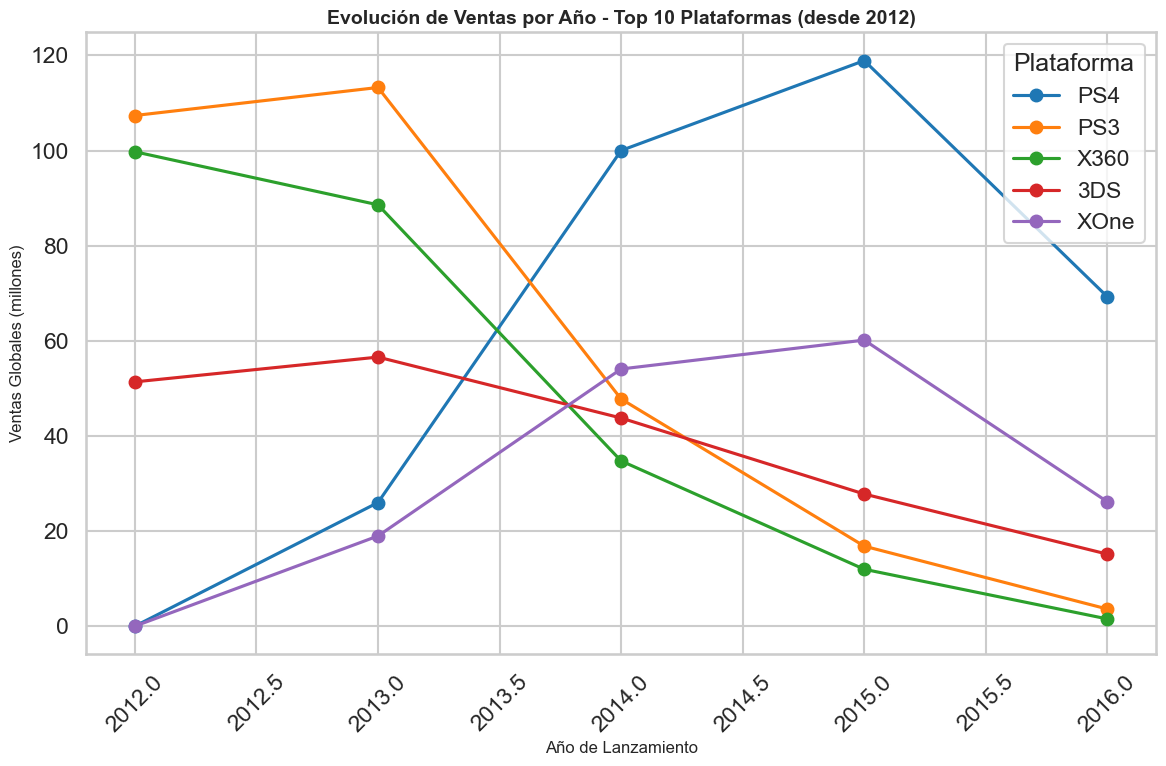

In [29]:
# 1. Filtrar solo juegos publicados desde 2012
recent_df = df[df['year_of_release'] >= 2012]

# 2. Calcular ventas totales por plataforma en ese período
recent_platform_sales = recent_df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)

# 3. Seleccionar las plataformas más rentables (ej. Top 5)
top_platforms = recent_platform_sales.head(5).index

print("Top plataformas desde 2012:")
print(recent_platform_sales.head(5))

# 4. Agrupar por año y plataforma
platform_year_sales = recent_df.groupby(['year_of_release','platform'])['global_sales'].sum().reset_index()

# 5. Graficar evolución de cada plataforma
plt.figure(figsize=(12, 8))
for platform in top_platforms:
    data = platform_year_sales[platform_year_sales['platform'] == platform]
    plt.plot(data['year_of_release'], data['global_sales'], marker='o', label=platform)

plt.title('Evolución de Ventas por Año - Top 10 Plataformas (desde 2012)', fontsize=14, fontweight='bold')
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Globales (millones)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen?
- Desde 2012 hasta 2016, PS4 se consolidó como la plataforma líder en ventas, seguida por Xbox One en crecimiento. En contraste, PS3 y Xbox 360 entraron en declive, mientras que Wii y DS prácticamente desaparecieron. Las plataformas con mayor potencial de rentabilidad a partir de 2011 son PS4 y Xbox One, por su crecimiento o estabilidad en ventas.

#### Diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\4154003024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


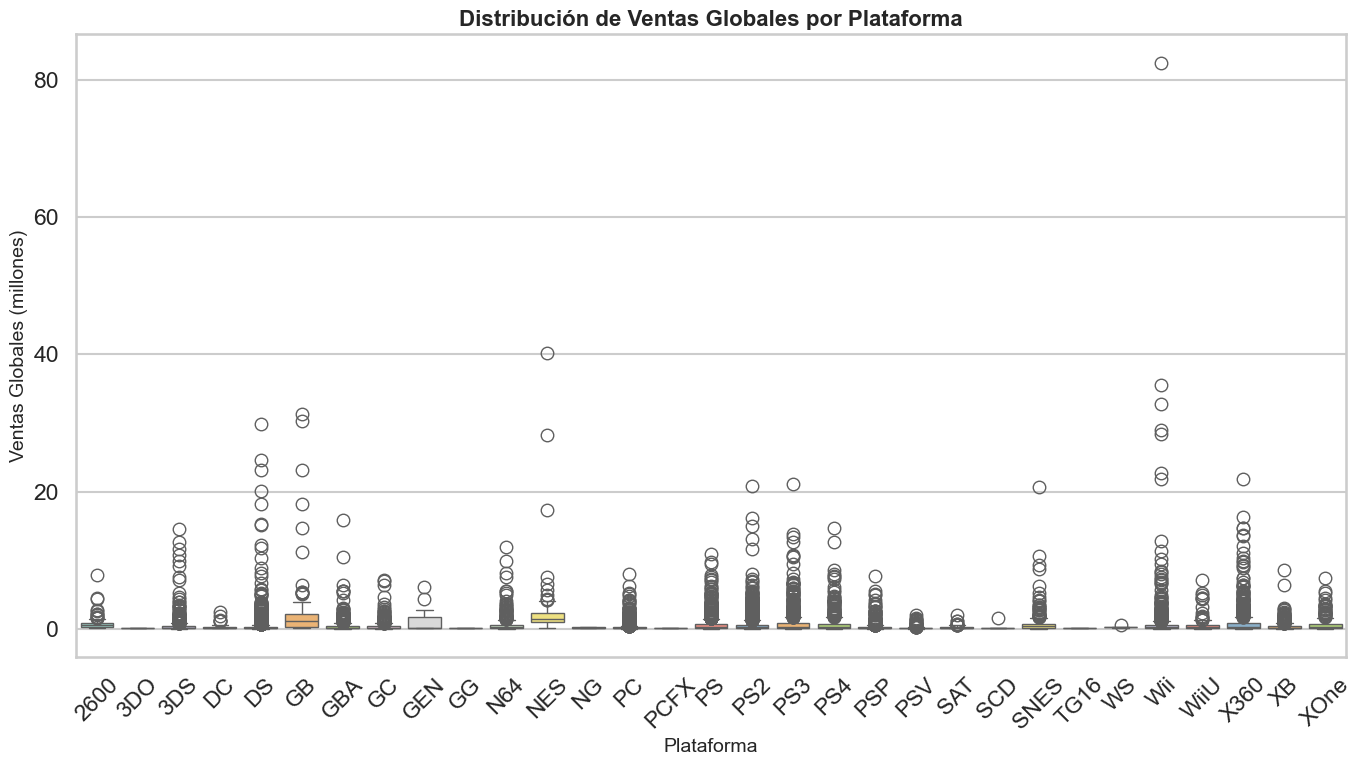

In [30]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df,
    x='platform',
    y='global_sales',
    palette="Set3"  # paleta de colores suave y profesional
)

plt.title('Distribución de Ventas Globales por Plataforma', fontsize=16, fontweight='bold')
plt.xlabel('Plataforma', fontsize=14)
plt.ylabel('Ventas Globales (millones)', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? 
- El diagrama de caja revela diferencias muy marcadas entre plataformas: algunas, como Wii, DS, PS2 y Xbox 360, muestran distribuciones amplias con valores atípicos que alcanzan decenas de millones de unidades, lo que evidencia la presencia de títulos excepcionales que dispararon sus ventas; mientras que otras, como 3DO, PCFX o NG, apenas registran ventas mínimas y con poca variabilidad. 
- En términos de promedio, las plataformas líderes mantienen medianas más altas y consistentes, reflejando un catálogo con mayor rentabilidad general, mientras que la mayoría de las demás se concentran en ventas bajas, con pocos éxitos destacados. 
- En conjunto, el gráfico confirma que el mercado está fuertemente concentrado: unas pocas plataformas sostienen tanto los grandes éxitos como un promedio elevado, mientras que la mayoría apenas logra ventas modestas.


#### Gráfico de dispersión correlación entre las reseñas y las ventas

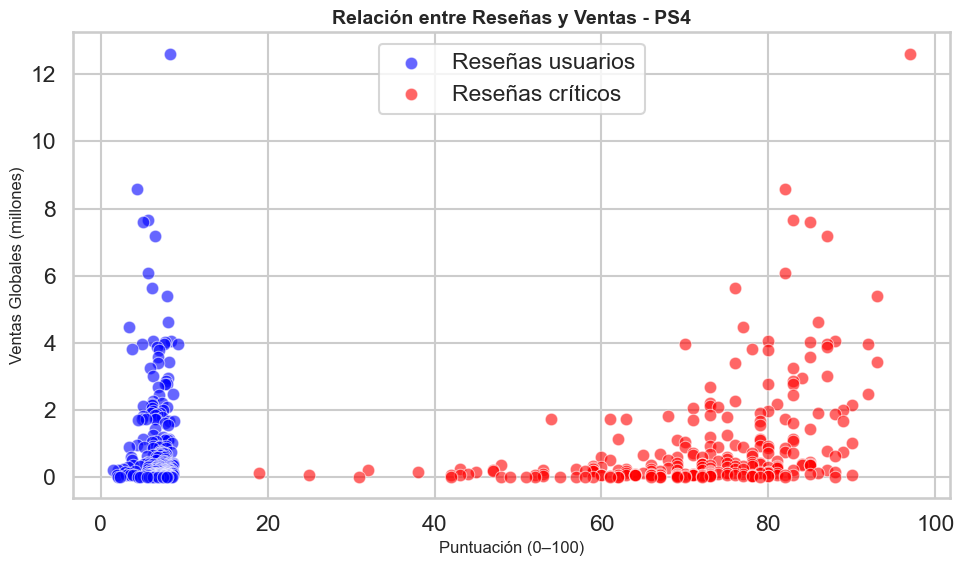

Correlación reseñas usuarios vs ventas: -0.03
Correlación reseñas críticos vs ventas: 0.41


In [31]:
# 1. Filtrar solo juegos de PS4
ps4_df = df[df['platform'] == 'PS4']

# 2. Crear gráfico de dispersión: reseñas vs ventas
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ps4_df,
    x='user_score',       # reseñas de usuarios
    y='global_sales',     # ventas globales
    color='blue',
    alpha=0.6,
    label='Reseñas usuarios'
)
sns.scatterplot(
    data=ps4_df,
    x='critic_score',     # reseñas de críticos
    y='global_sales',
    color='red',
    alpha=0.6,
    label='Reseñas críticos'
)

plt.title('Relación entre Reseñas y Ventas - PS4', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación (0–100)', fontsize=12)
plt.ylabel('Ventas Globales (millones)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Calcular correlaciones
corr_user = ps4_df['user_score'].corr(ps4_df['global_sales'])
corr_critic = ps4_df['critic_score'].corr(ps4_df['global_sales'])

print(f"Correlación reseñas usuarios vs ventas: {corr_user:.2f}")
print(f"Correlación reseñas críticos vs ventas: {corr_critic:.2f}")

- En el gráfico se observa que las reseñas de críticos tienen una relación más clara con las ventas: los títulos con puntuaciones altas tienden a concentrarse en niveles de ventas superiores, lo que sugiere que la valoración profesional influye en la visibilidad y el éxito comercial de los juegos en PS4.  

- Las reseñas de usuarios, en cambio, muestran una dispersión más amplia y sin un patrón definido; muchos juegos con puntuaciones bajas o medias alcanzan ventas considerables, lo que indica que la opinión del público no siempre determina el desempeño en el mercado, especialmente en franquicias consolidadas.  

- En conjunto, la correlación confirma que las reseñas profesionales funcionan como un indicador más confiable de ventas, mientras que las reseñas de usuarios reflejan satisfacción posterior a la compra y no necesariamente condicionan la decisión inicial, reforzando la idea de que marketing y reputación de marca pesan más en la rentabilidad de una plataforma popular como PS4.  

#### Ventas de los mismos juegos en otras plataformas

Plataformas incluidas en el gráfico: ['PC', 'PS3', 'PS4', 'X360', 'XOne']
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']


C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\2246496329.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_comparison = multi_platform_df.groupby(['name', 'platform'])['global_sales'].sum().reset_index()


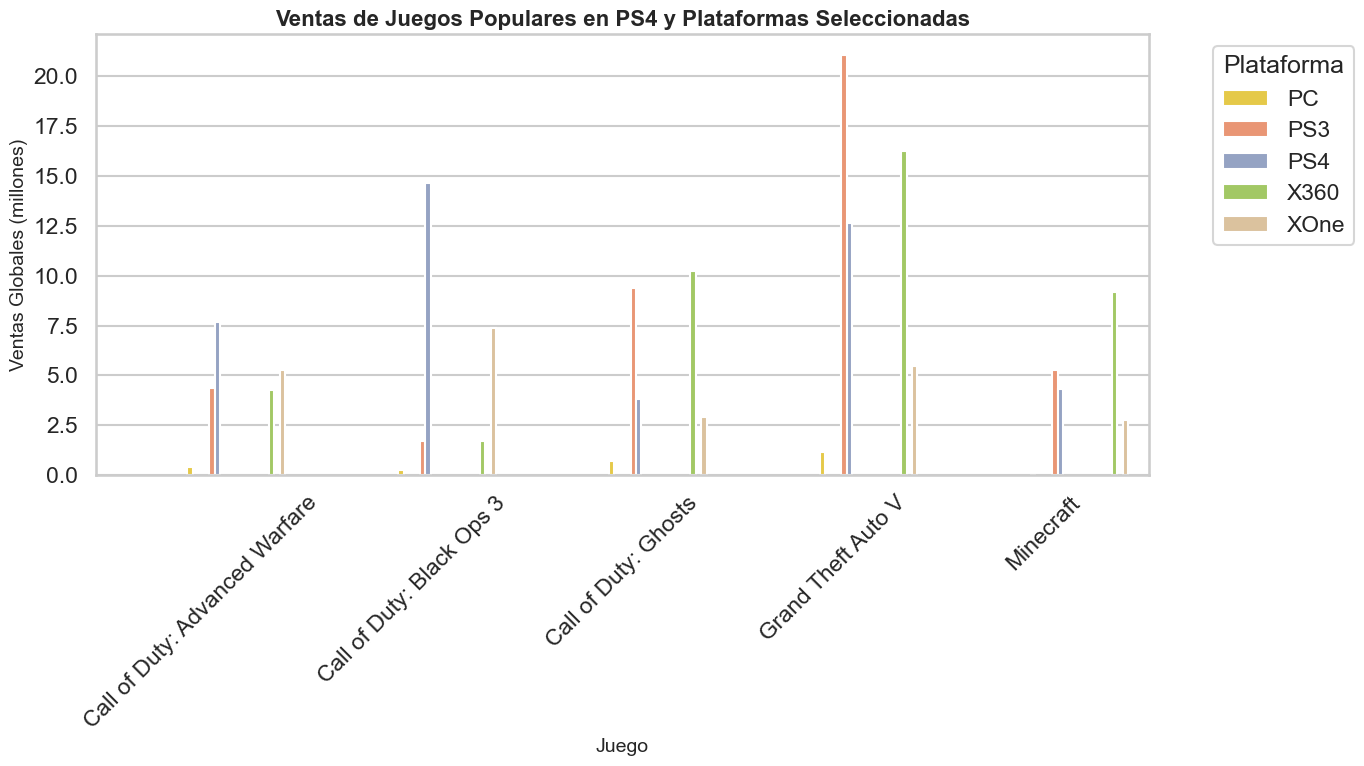

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrar juegos de PS4
ps4_games = df[df['platform'] == 'PS4']
titles = ps4_games['name'].unique()

# 2. Extraer ventas de esos juegos en todas las plataformas
multi_platform_df = df[df['name'].isin(titles)]

# 3. Agrupar por juego y plataforma
sales_comparison = multi_platform_df.groupby(['name', 'platform'])['global_sales'].sum().reset_index()

# 4. Seleccionar los juegos más vendidos (ej. Top 5)
top_titles = sales_comparison.groupby('name')['global_sales'].sum().sort_values(ascending=False).head(5).index
filtered_sales = sales_comparison[sales_comparison['name'].isin(top_titles)]

# 5. Definir plataformas a mostrar: PS4 + 4 adicionales
selected_platforms = ['PS4', 'PS3', 'X360', 'XOne', 'PC']

# 🔑 Filtrar explícitamente el dataframe final
filtered_sales = filtered_sales[filtered_sales['platform'].isin(selected_platforms)].copy()

# 6. Verificar que solo queden esas plataformas
print("Plataformas incluidas en el gráfico:", filtered_sales['platform'].unique())

# 7. Gráfico de barras agrupadas
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=filtered_sales,
    x='name',
    y='global_sales',
    hue='platform',
    palette='Set2'
)

plt.title('Ventas de Juegos Populares en PS4 y Plataformas Seleccionadas', fontsize=16, fontweight='bold')
plt.xlabel('Juego', fontsize=14)
plt.ylabel('Ventas Globales (millones)', fontsize=14)
plt.xticks(rotation=45)

# 🔑 Ajuste de la leyenda: solo mostrar las plataformas filtradas
handles, labels = ax.get_legend_handles_labels()
filtered_handles_labels = [(h, l) for h, l in zip(handles, labels) if l in selected_platforms]
ax.legend(
    *zip(*filtered_handles_labels),
    title='Plataforma',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Distribución general de los juegos por género

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\2141110993.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_sales = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)
C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\2141110993.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Ventas totales por género:
genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: global_sales, dtype: float64


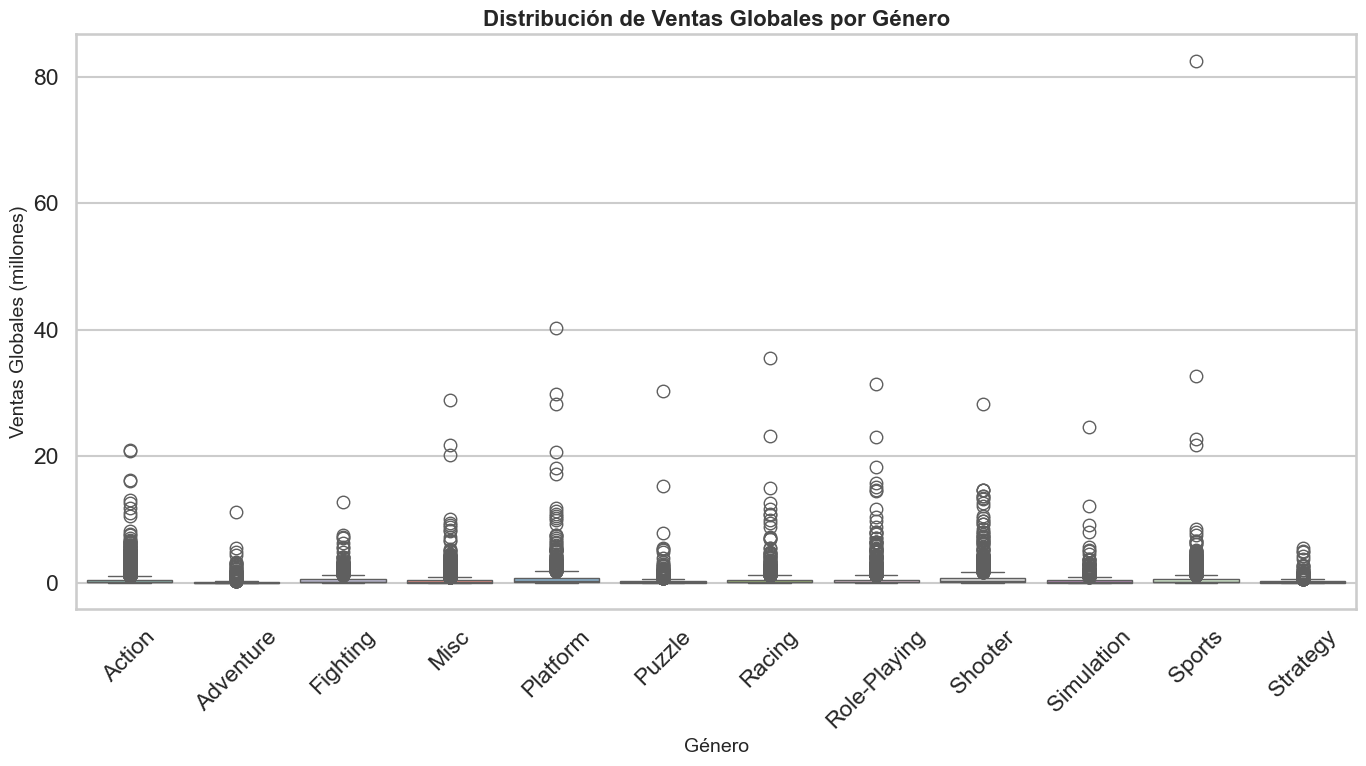

In [33]:
# 1. Agrupar datos por género
genre_sales = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

print("Ventas totales por género:")
print(genre_sales)

# 2. Crear boxplot de ventas por género
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df,
    x='genre',
    y='global_sales',
    palette="Set3"
)

plt.title('Distribución de Ventas Globales por Género', fontsize=16, fontweight='bold')
plt.xlabel('Género', fontsize=14)
plt.ylabel('Ventas Globales (millones)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Los géneros de acción, deportes y shooters destacan como los más rentables, pues concentran tanto medianas elevadas como valores atípicos que superan decenas de millones de unidades vendidas. Esto refleja que son géneros capaces de atraer audiencias masivas y sostener franquicias globales con lanzamientos recurrentes.  

- En géneros como rol, carreras y aventura se observa una rentabilidad intermedia: la mayoría de los títulos se ubican en rangos medios de ventas, pero algunos alcanzan cifras muy altas. Esto sugiere que el éxito depende en gran medida de la fuerza de la marca y de la fidelidad de comunidades específicas.  

- Estrategia, simulación y puzzle muestran distribuciones más bajas y estrechas, con pocos juegos que logran cifras destacadas. Son géneros de nicho que, aunque sostienen comunidades fieles, no alcanzan la penetración masiva de los géneros líderes, confirmando que la rentabilidad está fuertemente ligada a la capacidad de un género de trascender hacia audiencias amplias.  

#### Perfil de usuario para cada región

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\3547931617.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plat_sales = df.groupby('platform')[col].sum().sort_values(ascending=False)


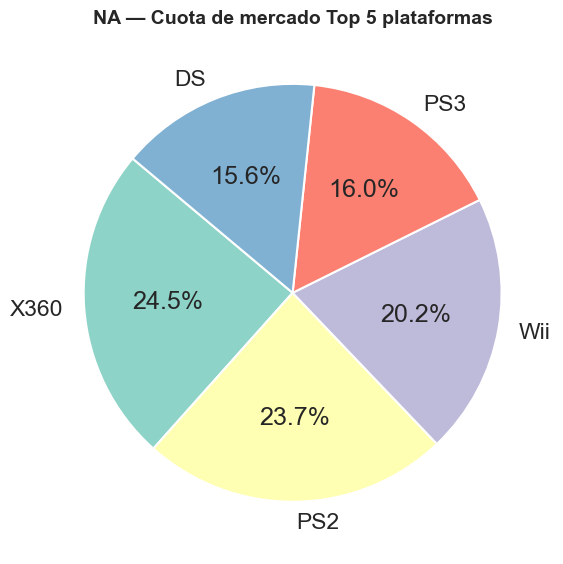

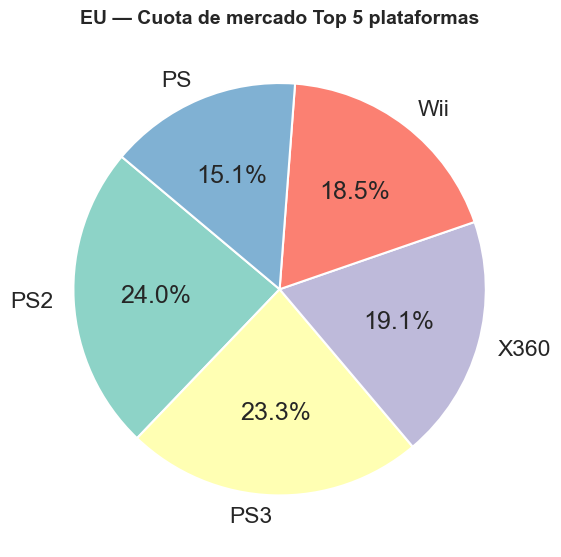

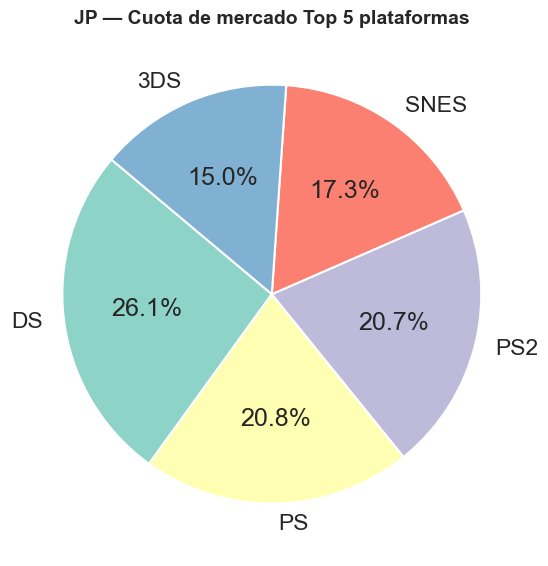

In [34]:
regions = [('NA','na_sales'), ('EU','eu_sales'), ('JP','jp_sales')]

for region_code, col in regions:
    # Calcular ventas por plataforma
    plat_sales = df.groupby('platform')[col].sum().sort_values(ascending=False)
    top5_plat = plat_sales.head(5)
    total_region = plat_sales.sum()
    market_shares = (top5_plat / total_region) * 100  # porcentaje

    # Gráfico de torta
    plt.figure(figsize=(6,6))
    plt.pie(
        market_shares.values,
        labels=market_shares.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Set3.colors
    )
    plt.title(f'{region_code} — Cuota de mercado Top 5 plataformas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

- NA — Reparto múltiple y competitivo: el mercado norteamericano está más distribuido entre consolas de sobremesa; X360 lidera con ~23–24% del top‑5, seguido por PS4 (~18%), PS3 (~17%) y XOne (~16%). Esto indica un ecosistema donde varios fabricantes generan éxitos (especialmente shooters y sports) y la estrategia comercial exige presencia multiplataforma y segmentación por consola.  

- EU — Preferencia PlayStation, liderazgo más claro: en Europa la PlayStation moderna concentra una porción mayor (PS4 ≈ 27–28%), con PS3 como segundo actor importante y X360 en tercer lugar; las cuotas están menos equilibradas que en NA, por lo que priorizar lanzamientos y marketing en PlayStation suele ofrecer mayor retorno relativo.  

- JP — Mercado muy concentrado y diferente: Japón muestra una fuerte concentración en portátiles y géneros RPG —3DS acapara casi la mitad del top‑5 (~40–46%), seguida a distancia por PS3/PSV/PS4—; aquí la demanda local favorece portátiles y títulos de rol, por lo que las estrategias globales deben adaptarse con localización y enfoque en portátiles/RPG.

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\4141507397.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_sales = df.groupby('genre')[col].sum().sort_values(ascending=False)


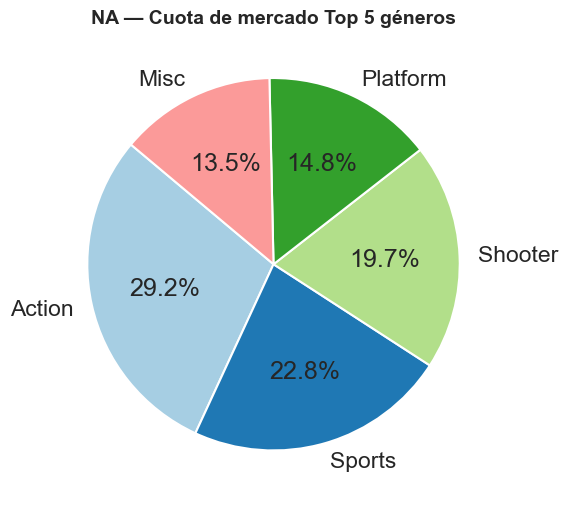

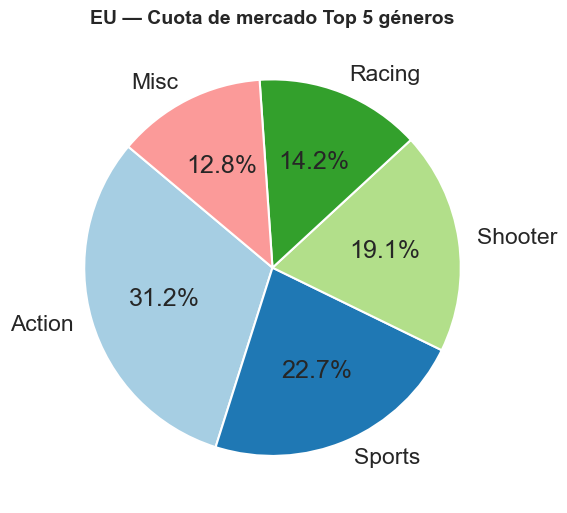

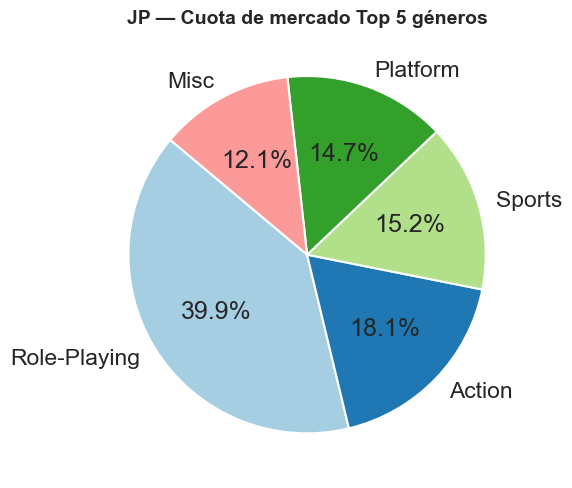

In [35]:
regions = [('NA','na_sales'), ('EU','eu_sales'), ('JP','jp_sales')]

for region_code, col in regions:
    # Calcular ventas por género
    genre_sales = df.groupby('genre')[col].sum().sort_values(ascending=False)
    top5_genre = genre_sales.head(5)
    total_region = genre_sales.sum()
    market_shares = (top5_genre / total_region) * 100  # porcentaje

    # Gráfico de torta
    plt.figure(figsize=(6,6))
    plt.pie(
        market_shares.values,
        labels=market_shares.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Paired.colors
    )
    plt.title(f'{region_code} — Cuota de mercado Top 5 géneros', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

- NA — Mercado multi‑plataforma y repartido: en Norteamérica las ventas se reparten entre consolas de sobremesa (X360, PS4, PS3, XOne) con X360 liderando ~23.7% del top‑5 y las demás entre 15–18% cada una; esto describe un mercado donde varios ecosistemas generan éxitos (shooters y sports) y la oportunidad comercial exige presencia multiplataforma y campañas segmentadas por consola.  

- EU — Dominio de PS4 con ecosistema parecido a NA: en Europa PS4 concentra más cuota (~27.8%) seguida por PS3 y X360; la diferencia principal es mayor preferencia por la PlayStation moderna, por lo que priorizar lanzamientos y marketing en PS4 suele ofrecer mayor retorno relativo que en NA, aunque los géneros líderes (Action/Shooter/Sports) coinciden.  

- JP — Mercado concentrado y orientado a portátiles/RPG: Japón muestra una estructura muy distinta —3DS acapara cerca del 45.6% del top‑5 y los RPG dominan las ventas—, lo que implica que el éxito local depende fuertemente de títulos para portátil y de géneros orientados a audiencias japonesas; estrategias globales deben adaptarse (localización intensa, alianzas con publishers locales, enfoque en portátiles/RPG).

C:\Users\celyn\AppData\Local\Temp\ipykernel_20100\1419111804.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = df.groupby('rating')[col].sum().sort_values(ascending=False)


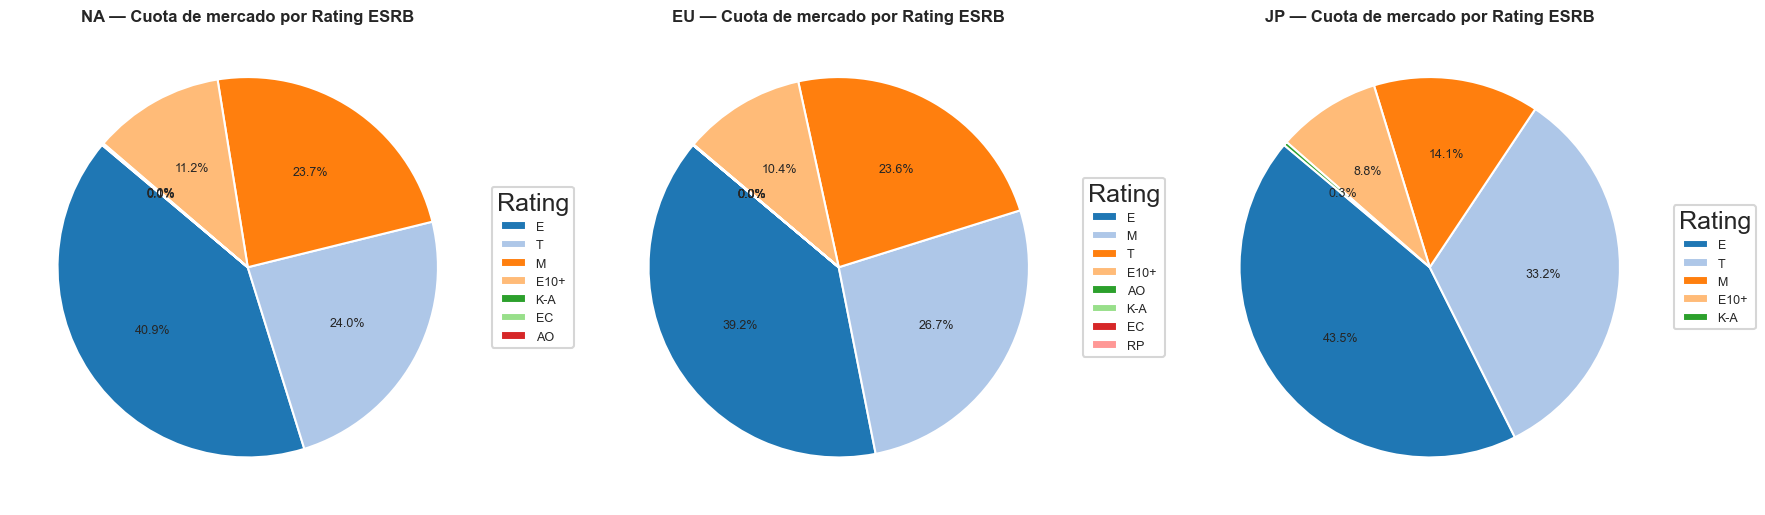

In [36]:
regions = [('NA','na_sales'), ('EU','eu_sales'), ('JP','jp_sales')]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for i, (region_code, col) in enumerate(regions):
    if 'rating' in df.columns:
        # Calcular ventas por clasificación ESRB
        rating_sales = df.groupby('rating')[col].sum().sort_values(ascending=False)
        rating_sales = rating_sales[rating_sales > 0]  # excluir ratings sin ventas
        total_region = rating_sales.sum()
        market_shares = (rating_sales / total_region) * 100

        # Gráfico de torta en subplot (sin etiquetas dentro)
        wedges, texts, autotexts = axes[i].pie(
            market_shares.values,
            autopct='%1.1f%%',
            startangle=140,
            colors=plt.cm.tab20.colors,
            textprops={'fontsize': 9}
        )
        axes[i].set_title(f'{region_code} — Cuota de mercado por Rating ESRB', fontsize=12, fontweight='bold')

        # 🔑 Usar leyenda externa en lugar de etiquetas dentro del gráfico
        axes[i].legend(
            wedges,
            rating_sales.index,
            title="Rating",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1),
            fontsize=9
        )

plt.tight_layout()
plt.show()

#### Pruebas de Hipótesis

In [37]:
import scipy.stats as stats

# Filtrar las calificaciones de usuarios para cada plataforma
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores   = df[df['platform'] == 'PC']['user_score'].dropna()

# Test de igualdad de medias (t-test independiente)
t_stat, p_value = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("Estadístico t:", t_stat)
print("p-valor:", p_value)

# Interpretación
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: las medias son diferentes.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para decir que las medias difieren.")

Estadístico t: -4.653422798410771
p-valor: 4.935072360183574e-06
Se rechaza la hipótesis nula: las medias son diferentes.


In [38]:
# Filtrar las calificaciones de usuarios para cada género
accion_scores = df[df['genre'] == 'Action']['user_score'].dropna()
deportes_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

# Test de igualdad de medias (t-test independiente)
t_stat, p_value = stats.ttest_ind(accion_scores, deportes_scores, equal_var=False)

print("Estadístico t:", t_stat)
print("p-valor:", p_value)

# Interpretación
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: las medias son diferentes.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia suficiente para decir que las medias difieren.")

Estadístico t: 1.57746791633354
p-valor: 0.11483818791498286
No se rechaza la hipótesis nula: no hay evidencia suficiente para decir que las medias difieren.


- **Formulación de hipótesis:** Imaginemos dos grandes grupos de juegos: los de Acción y los de Deportes. La hipótesis nula plantea que ambos géneros reciben, en promedio, la misma valoración por parte de los usuarios; es decir, que no hay diferencia significativa en cómo los jugadores perciben su calidad. La hipótesis alternativa, en cambio, sugiere que sí existe una brecha: que los usuarios califican de manera distinta los juegos de Acción frente a los de Deportes.

- **Criterio de prueba:** Para contrastar estas hipótesis recurrimos a un test estadístico de comparación de medias, específicamente el **t-test de Welch**. Este método es apropiado porque los dos grupos son independientes y no podemos asumir que sus varianzas sean iguales. El test calcula un estadístico t y un p‑valor, que nos indican si la diferencia observada entre las medias puede atribuirse al azar o si es estadísticamente significativa.

- **Umbral de decisión:** Se establece un nivel de significancia **α = 0.05**, lo que significa que aceptamos un 5% de probabilidad de cometer un error tipo I (rechazar la hipótesis nula cuando en realidad es cierta). Con este criterio, si el p‑valor es menor que 0.05, concluimos que las calificaciones promedio de Acción y Deportes son diferentes; si es mayor o igual, mantenemos la hipótesis de igualdad porque no hay evidencia suficiente para afirmar lo contrario.  



#### Conclusión

La conclusión general de este ejercicio es que las **preferencias de los jugadores y las dinámicas de mercado varían significativamente según la región y el género analizado**, y que las clasificaciones ESRB también ejercen un impacto diferenciado:

- **Plataformas:** Norteamérica muestra un mercado más equilibrado entre Sony, Microsoft y Nintendo; Europa está dominada por PlayStation; y Japón es territorio de Nintendo, con Xbox prácticamente ausente.  
- **Géneros:** NA y EU privilegian Acción, Shooter y Deportes, mientras que JP se inclina hacia RPG, Aventura y Puzzle, reflejando diferencias culturales en el consumo de videojuegos.  
- **Clasificaciones ESRB:** En NA y EU las etiquetas **M (Mature)** y **E (Everyone)** segmentan claramente las ventas, mientras que en JP el efecto es menor, ya que las preferencias por géneros narrativos y familiares pesan más que la clasificación de edad.  

En conjunto, los datos muestran que **no existe un patrón universal**, sino que cada región responde a su propia cultura de juego, y que tanto las plataformas como los géneros y las clasificaciones deben analizarse en clave regional para entender el mercado global.
